פרויקט מדעי הנתונים הכפר הירוק כיתה י

עידן עטר ת"ז 318074846

שם מורה: ענת שפיר

מטרת מחקר: לחזות אם תלמיד נשר מאוניברסיטה או לא

https://www.kaggle.com/datasets/meharshanali/student-dropout-prediction-dataset

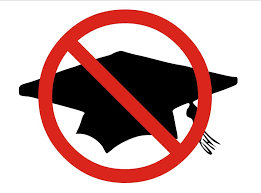

פירוט על המאגר

Student_ID: מזהה סטודנט ייחודי.

Age: גיל הסטודנט בשנים.

Gender: Male / Female (מין).

Family_Income: הכנסה משפחתית חודשית.

Internet_Access: Yes / No (גישה לאינטרנט).

Study_Hours_per_Day: ממוצע שעות לימוד ביום.

Attendance_Rate: אחוז נוכחות.

Assignment_Delay_Days: ממוצע ימי עיכוב בהגשת מטלות.

Travel_Time_Minutes: זמן נסיעה יומי בדקות.

Part_Time_Job: Yes / No (עבודה במשרה חלקית).

Scholarship: Yes / No (מלגה).

Stress_Index: מדד לחץ בדיווח עצמי (1–10).

GPA, Semester_GPA, CGPA: ביצועים אקדמיים (ממוצעים).

Semester: שנת לימודים נוכחית (Year 1–4).

Department: Science, Arts, Business, CS, Engineering (מחלקה/פקולטה).

Parental_Education: השכלה גבוהה ביותר של ההורים.

מאפייני סט הנתונים:

שורות: 10,000.

עמודות: 19.

שיעור נשירה (Dropout rate): 23.5%.

מכיל משתנים קטגוריאליים ומספריים כאחד.
10% משתנים חסרים

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import Perceptron
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.neural_network import MLPClassifier

נעשה אינטרגציה לנתונים מהמאגר מידע

In [3]:
path = kagglehub.dataset_download("meharshanali/student-dropout-prediction-dataset")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, csv_files[0]))

print("הנתונים נטענו בהצלחה!")
print(df.head())

100%|██████████| 255k/255k [00:00<00:00, 60.7MB/s]

Extracting files...
הנתונים נטענו בהצלחה!
   Student_ID   Age  Gender  Family_Income Internet_Access  \
0           1  22.1    Male        25000.0             Yes   
1           2  20.7    Male        25000.0             Yes   
2           3  22.4    Male        40183.0             Yes   
3           4  24.4    Male            NaN             Yes   
4           5  20.5  Female        25319.0             Yes   

   Study_Hours_per_Day  Attendance_Rate  Assignment_Delay_Days  \
0                 3.36             86.1                      2   
1                 4.30             68.0                      2   
2                 4.40             70.9                      0   
3                  NaN             82.2                      2   
4                 4.19             75.7                      1   

   Travel_Time_Minutes Part_Time_Job Scholarship  Stress_Index   GPA  \
0                 20.4           Yes          No           5.5  0.96   
1                 44.0            No        

ניקוי  וסידור נתונים

In [4]:
df_cleaned = df.dropna()

# הדפסת סיכום
print(f"שורות לפני ניקוי: {len(df)}")
print(f"שורות אחרי ניקוי: {len(df_cleaned)}")

שורות לפני ניקוי: 10000
שורות אחרי ניקוי: 9020


כל הנתונים קיימים

נעשה מפה תרמית כדי שנדע לאיזה ערכים יש הכי הרבה קורלציה

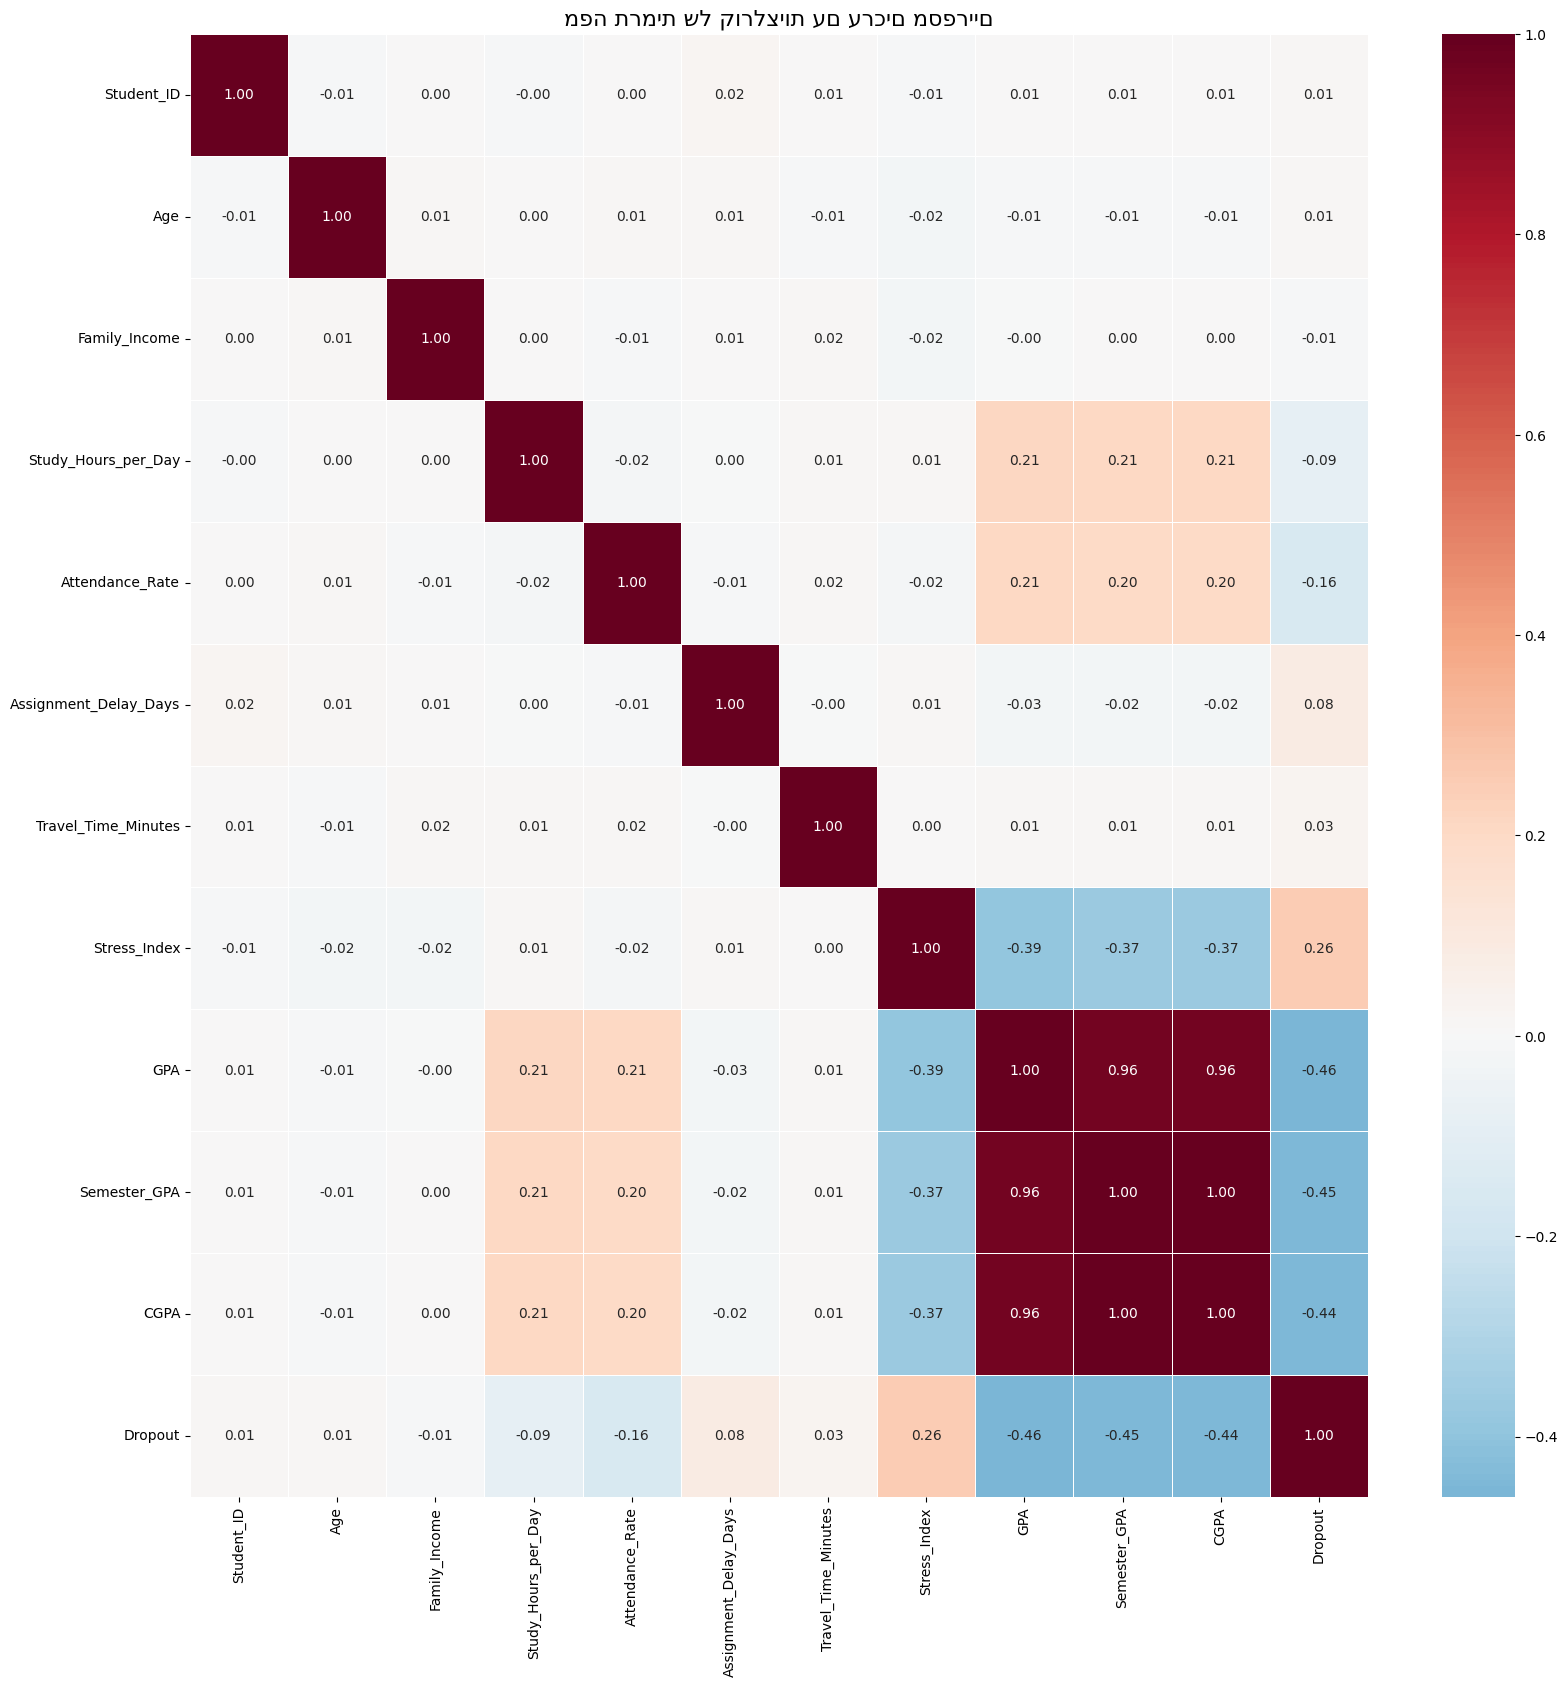

In [5]:
# 1. בחירת העמודות המספריות בלבד
numeric_df = df_cleaned.select_dtypes(include=['number'])

# 2. חישוב מטריצת הקורלציה
corr_matrix = numeric_df.corr()

top_corr_features = corr_matrix.index[:19]

# 4. יצירת המפה התרמית עם מספרים (annot=True)
plt.figure(figsize=(19, 19))
sns.heatmap(df[top_corr_features].corr(),
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            linewidths=0.5)

plt.title("מפה תרמית של קורלציות עם ערכים מספריים", fontsize=16)
plt.show()

לפי המפה נשתמש בערכים

Stress_Index, GPA, Assignment_Delay_Days, Attendance_Rate, Study_Hours_per_Day



In [6]:
FEATURES = ['Stress_Index', 'GPA', 'Attendance_Rate', 'Assignment_Delay_Days',]
TARGET   = 'Dropout'

print("Dataset shape:", df_cleaned.shape)
print("\nTarget distribution:")
print(df_cleaned[TARGET].value_counts())

x = df_cleaned[FEATURES]
y = df_cleaned[TARGET]

if y.dtype == object:
    le = LabelEncoder()
    y = le.fit_transform(y)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Dataset shape: (9020, 19)

Target distribution:
Dropout
0    6902
1    2118
Name: count, dtype: int64


נראה גרף המראה את ההתפלגות של המשתנים כדי להראות קורלציה באופן ויזואלי

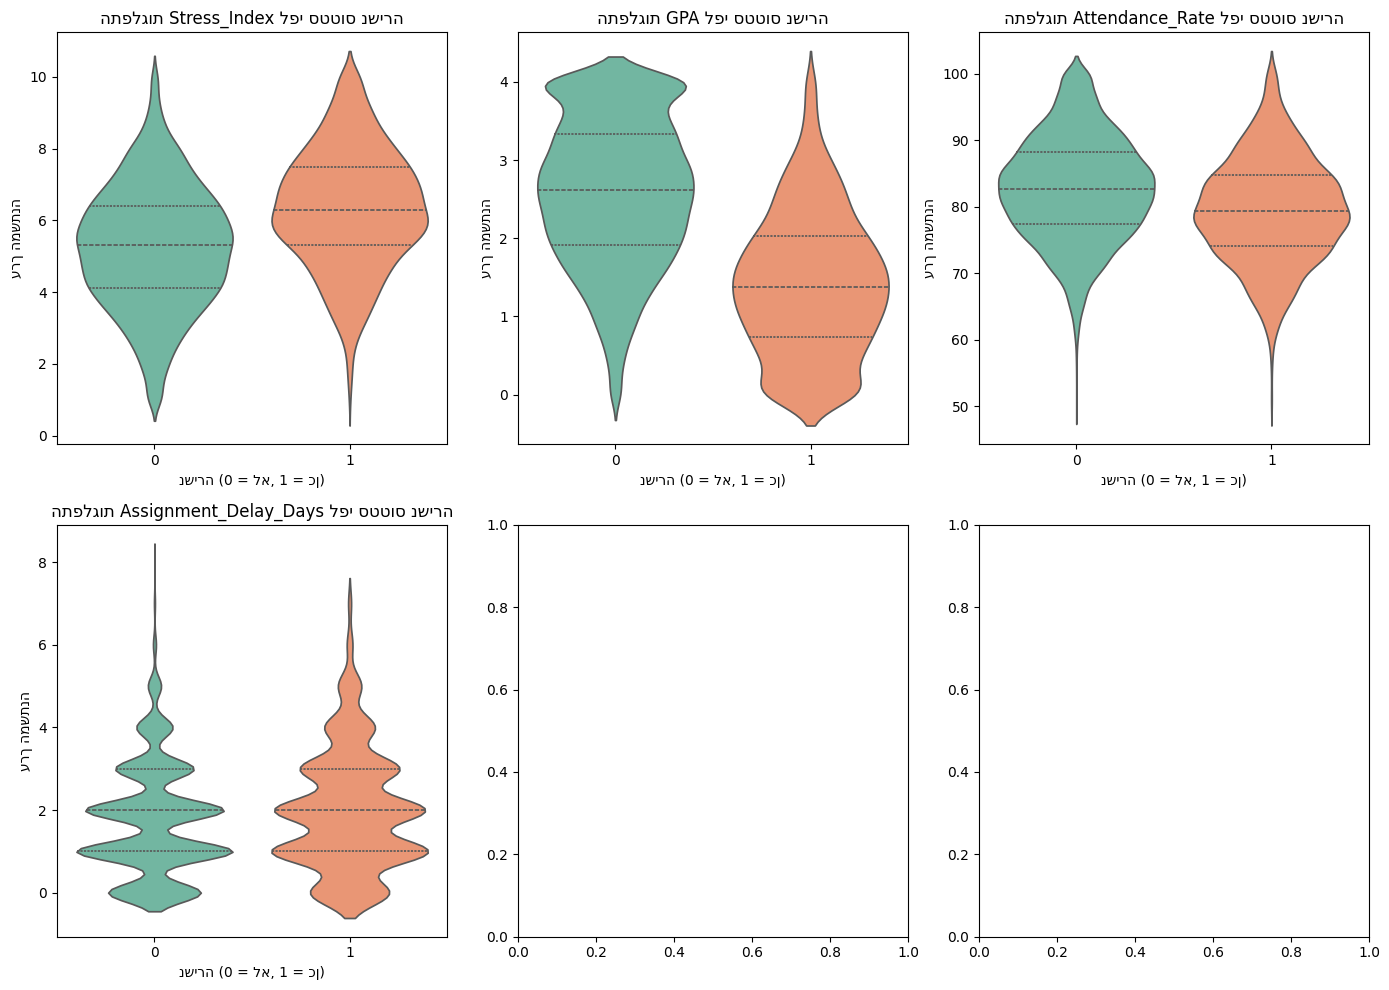

In [7]:
# @title


fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    sns.violinplot(x='Dropout', y=col, data=df_cleaned, ax=axes[i], palette="Set2", inner="quartile")
    axes[i].set_title(f'התפלגות {col} לפי סטטוס נשירה', fontsize=12)
    axes[i].set_xlabel('נשירה (0 = לא, 1 = כן)')
    axes[i].set_ylabel('ערך המשתנה')

plt.tight_layout()
plt.show()

נראה גרף המראה את ההבדל בין הנושרים לממשיכים

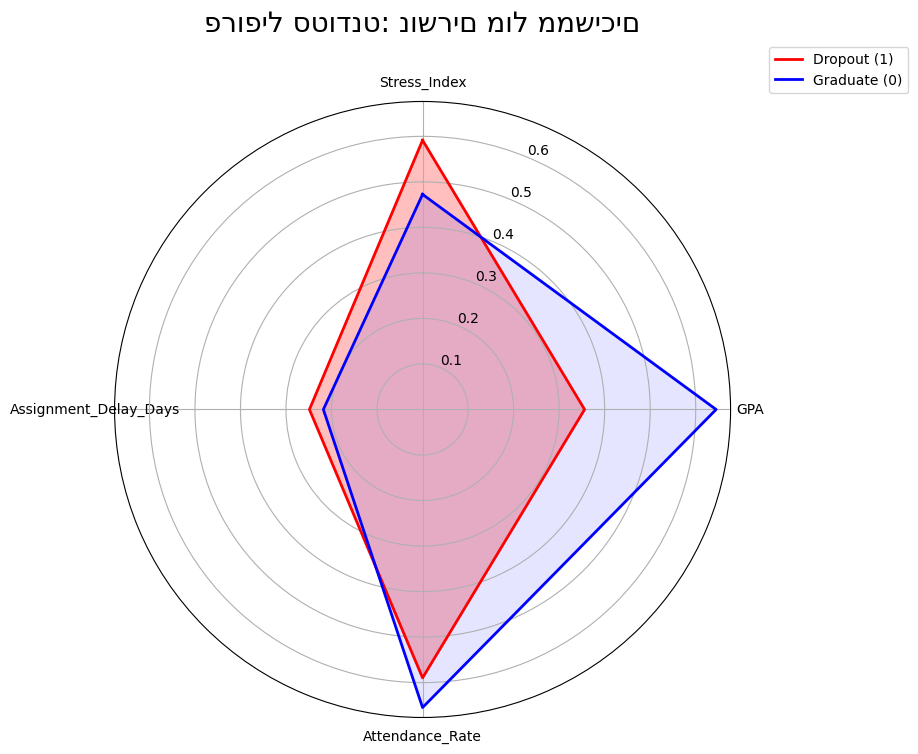

In [8]:
# @title
from sklearn.preprocessing import MinMaxScaler
scaler_radar = MinMaxScaler()
df_radar = pd.DataFrame(scaler_radar.fit_transform(df_cleaned[FEATURES]), columns=FEATURES)
df_radar['Dropout'] = df_cleaned['Dropout'].values

# חישוב ממוצע לכל קבוצה
categories = FEATURES
N = len(categories)

# ממוצע נושרים וממוצע ממשיכים
avg_dropout = df_radar[df_radar['Dropout'] == 1][categories].mean().tolist()
avg_graduate = df_radar[df_radar['Dropout'] == 0][categories].mean().tolist()

# סגירת המעגל של הגרף (הוספת הערך הראשון בסוף)
avg_dropout += avg_dropout[:1]
avg_graduate += avg_graduate[:1]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# 2. שרטוט הגרף
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# קבוצת הנושרים
ax.plot(angles, avg_dropout, color='red', linewidth=2, label='Dropout (1)')
ax.fill(angles, avg_dropout, color='red', alpha=0.25)

# קבוצת הממשיכים
ax.plot(angles, avg_graduate, color='blue', linewidth=2, label='Graduate (0)')
ax.fill(angles, avg_graduate, color='blue', alpha=0.1)

# הגדרות אסתטיות
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories)

plt.title('פרופיל סטודנט: נושרים מול ממשיכים', size=20, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

נחלק לקבוצות ציונים

In [9]:
# @title

df_cleaned['GPA_Group'] = pd.cut(df_cleaned['GPA'], bins=[0, 2, 3, 4], labels=['Low', 'Medium', 'High'])

dropout_rate = df_cleaned.groupby('GPA_Group')['Dropout'].mean() * 100
print(dropout_rate)

GPA_Group
Low       42.762763
Medium    14.821067
High       4.138747
Name: Dropout, dtype: float64


לפי ההרצה אפשר לראות שההבדל בין הנשירה של בינוני לנמוך הרבה יותר גדולה מההפרש בין בינוני לגבוה וזה אומר שהשפעת הציונים על אחוזי נשירה מתעצמת ככל שהציונים יורדים

נראה טבלה המתארת את האינטרקציה בין ציונים לנשירה






In [10]:
# @title

stats = df_cleaned.groupby('Dropout')['GPA'].agg(['mean', 'median', 'min', 'max'])
print(stats)

             mean  median  min  max
Dropout                            
0        2.579312    2.62  0.0  4.0
1        1.423621    1.38  0.0  4.0


אפשר לראות שהסטודנטים שנשרו היו ציונים משמעותית יותר נמוכים מאלה שלא

חלק ג

נפתור בעיות באיזון

In [ ]:
# @title
# ════════════════════════════════════════════════════════
# Feature Subset Selection
# Best combo from 5 candidates (3-5 features via 5-Fold CV)
# ════════════════════════════════════════════════════════
from itertools import combinations

ALL_5_FEATURES = ['Stress_Index', 'GPA', 'Attendance_Rate',
                  'Assignment_Delay_Days', 'Study_Hours_per_Day']

# Re-split with all 5 features so any subset can be tested
x5       = df_cleaned[ALL_5_FEATURES]
y5       = y  # encoded in cell 12

x5_train, x5_test, _, _ = train_test_split(x5, y5, test_size=0.2, random_state=42)

cv_fs   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fs_results = {}
best_combo    = list(FEATURES)
best_fs_score = 0.0

print("=== Feature Subset Selection (3-5 features from 5 candidates) ===\n")
for r in range(3, len(ALL_5_FEATURES) + 1):
    for combo in combinations(ALL_5_FEATURES, r):
        pipe = ImbPipeline([
            ('smote',  SMOTE(sampling_strategy=0.9, random_state=42)),
            ('scaler', StandardScaler()),
            ('clf',    SVC(kernel='rbf', C=10, random_state=42)),
        ])
        scores = cross_val_score(pipe, x5_train[list(combo)], y_train,
                                 cv=cv_fs, scoring='f1_macro', n_jobs=-1)
        fs_results[combo] = scores.mean()
        if scores.mean() > best_fs_score:
            best_fs_score = scores.mean()
            best_combo    = list(combo)

top10 = sorted(fs_results.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 feature combinations:")
for combo, score in top10:
    marker = " ◀ best" if list(combo) == best_combo else ""
    print(f"  {list(combo)}  →  F1-macro: {score:.4f}{marker}")

BEST_FEATURES = best_combo
print(f"\n✓ Best feature set: {BEST_FEATURES}  (CV F1-macro: {best_fs_score:.4f})")

# Update x_train / x_test to use the best feature subset
x_train = x5_train[BEST_FEATURES].reset_index(drop=True)
x_test  = x5_test [BEST_FEATURES].reset_index(drop=True)


In [ ]:
# @title
# ════════════════════════════════════════════════════════
# Feature Engineering
# Tests interaction & ratio features; adopts them only if
# they improve CV F1-macro over the best base feature set.
# ════════════════════════════════════════════════════════

df_fe = df_cleaned.copy()

# Interaction / ratio features
df_fe['GPA_x_Attend']     = df_fe['GPA']          * df_fe['Attendance_Rate']
df_fe['Stress_per_Study']  = df_fe['Stress_Index'] / (df_fe['Study_Hours_per_Day'] + 1)
df_fe['Delay_x_Stress']    = df_fe['Assignment_Delay_Days'] * df_fe['Stress_Index']
df_fe['Study_GPA_ratio']   = df_fe['GPA']          / (df_fe['Study_Hours_per_Day'] + 1)

ENG_EXTRAS   = ['GPA_x_Attend', 'Stress_per_Study', 'Delay_x_Stress', 'Study_GPA_ratio']
ENG_FEATURES = BEST_FEATURES + ENG_EXTRAS

# Align to the same train/test indices used by x5_train / x5_test
x_eng_train = df_fe.loc[x5_train.index, ENG_FEATURES].reset_index(drop=True)
x_eng_test  = df_fe.loc[x5_test.index,  ENG_FEATURES].reset_index(drop=True)

def cv_f1(X, y_):
    pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=0.9, random_state=42)),
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, random_state=42)),
    ])
    return cross_val_score(pipe, X, y_, cv=cv_fs, scoring='f1_macro', n_jobs=-1)

scores_base = cv_f1(x_train,     y_train)
scores_eng  = cv_f1(x_eng_train, y_train)

print("=== Feature Engineering Evaluation ===")
print(f"Base features ({len(BEST_FEATURES)}):       F1-macro = {scores_base.mean():.4f} ± {scores_base.std():.4f}")
print(f"+ Engineered  ({len(ENG_FEATURES)}): F1-macro = {scores_eng.mean():.4f} ± {scores_eng.std():.4f}")

print("\nEngineered extras tested:")
for f in ENG_EXTRAS:
    print(f"  {f}")

if scores_eng.mean() > scores_base.mean():
    print("\n✓ Feature engineering improves score — adopting engineered features.")
    x_train       = x_eng_train
    x_test        = x_eng_test
    BEST_FEATURES = ENG_FEATURES
else:
    print("\n✗ No improvement from feature engineering — keeping base features.")

print(f"\nFinal feature set ({len(BEST_FEATURES)}): {BEST_FEATURES}")


In [ ]:
# @title
# ════════════════════════════════════════════════════════
# SMOTE Sampling-Strategy Optimisation  (5 ratios × 5-fold)
# ════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

cv_smote = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote_strategies = [0.3, 0.5, 0.7, 0.9, 1.0]
best_smote_ratio = 0.9
best_smote_score = 0.0

print("=== SMOTE Sampling-Strategy Optimisation (5-Fold CV) ===")
for ratio in smote_strategies:
    pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=ratio, random_state=42)),
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, random_state=42)),
    ])
    scores = cross_val_score(pipe, x_train, y_train,
                             cv=cv_smote, scoring='f1_macro', n_jobs=-1)
    print(f"  ratio={ratio:.1f}  →  F1-macro: {scores.mean():.4f} ± {scores.std():.4f}")
    if scores.mean() > best_smote_score:
        best_smote_score = scores.mean()
        best_smote_ratio = ratio

print(f"\n✓ Best SMOTE ratio: {best_smote_ratio}  (CV F1-macro: {best_smote_score:.4f})")

sm = SMOTE(sampling_strategy=best_smote_ratio, random_state=42)
x_train_res, y_train_res = sm.fit_resample(x_train, y_train)
print(f"Balanced Training Balance: {Counter(y_train_res)}")




  ננרמל נתונים

In [12]:
# @title



scalers = {
    "mn": MinMaxScaler(),
    "std": StandardScaler()
}



נכין דוח מדדי הביצועים ומטריצת בלבול

In [13]:
# @title

def evaluate_model(name, y_test, y_pred):
    """
    7.2 - מטריצת בלבול + מדדי ביצוע לסיווג
    """
    print(f"\n{'=' * 55}")
    print(f"  {name}")
    print(f"{'=' * 55}")

    # 7.2.1 - Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # 7.2.2 + 7.2.3 - Precision / Recall / F1 (macro + weighted)
    prec_macro = precision_score(y_test, y_pred, average='macro',    zero_division=0)
    rec_macro  = recall_score   (y_test, y_pred, average='macro',    zero_division=0)
    f1_macro   = f1_score       (y_test, y_pred, average='macro',    zero_division=0)
    prec_w     = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec_w      = recall_score   (y_test, y_pred, average='weighted', zero_division=0)
    f1_w       = f1_score       (y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n{'Metric':<15} {'Macro (חשבוני)':<20} {'Weighted (משוקלל)'}")
    print(f"{'Precision':<15} {prec_macro:<20.4f} {prec_w:.4f}")
    print(f"{'Recall':<15} {rec_macro:<20.4f} {rec_w:.4f}")
    print(f"{'F1':<15} {f1_macro:<20.4f} {f1_w:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # מטריצת בלבול - שמירה לתמונה
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix\n{name}", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"cm_{name.replace(' ', '_').replace('/', '-')}.png", dpi=100)
    plt.close()

    return {
        'accuracy':           acc,
        'f1_macro':           f1_macro,
        'f1_weighted':        f1_w,
        'precision_macro':    prec_macro,
        'precision_weighted': prec_w,
        'recall_macro':       rec_macro,
        'recall_weighted':    rec_w,
    }

אימון וחיזוי כל המודלים

In [ ]:
# @title
# ════════════════════════════════════════════════════════
# Hyperparameter Tuning — both scalers (MinMax + Standard)
#   KNN  — GridSearchCV,       inner 5-fold, outer 10-fold
#   SVM  — RandomizedSearchCV, inner 3-fold, outer 5-fold
#   MLP  — RandomizedSearchCV, inner 3-fold, outer 5-fold
# ════════════════════════════════════════════════════════
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score

cv_knn_inner  = StratifiedKFold(n_splits=5,  shuffle=True, random_state=42)
cv_knn_outer  = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_fast_inner = StratifiedKFold(n_splits=3,  shuffle=True, random_state=42)
cv_fast_outer = StratifiedKFold(n_splits=5,  shuffle=True, random_state=42)

scalers = {'mn': MinMaxScaler(), 'std': StandardScaler()}

tuned_results = {}
best_models   = {}

for scaler_name, scaler_obj in scalers.items():

    print(f"\n\n{'#'*70}")
    print(f"  SCALER: {scaler_name.upper()}")
    print(f"{'#'*70}")

    # ── KNN ──────────────────────────────────────────────────────────────────
    print(f"\n{'='*62}")
    print(f"  KNN — GridSearchCV (inner 5-Fold) / {scaler_name}")
    print(f"{'='*62}")

    knn_pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=best_smote_ratio, random_state=42)),
        ('scaler', scaler_obj),
        ('clf',    KNeighborsClassifier()),
    ])
    knn_grid = {
        'clf__n_neighbors': [5, 11, 21, 31, 51],
        'clf__weights':     ['uniform', 'distance'],
        'clf__metric':      ['euclidean', 'manhattan'],
    }
    knn_search = GridSearchCV(knn_pipe, knn_grid,
                              cv=cv_knn_inner, scoring='f1_macro',
                              n_jobs=-1, verbose=0)
    knn_search.fit(x_train, y_train)
    y_pred = knn_search.best_estimator_.predict(x_test)
    print(f"Best params       : {knn_search.best_params_}")
    print(f"Inner-CV F1-macro : {knn_search.best_score_:.4f}")
    result = evaluate_model(f"KNN / {scaler_name}", y_test, y_pred)
    outer = cross_val_score(knn_search.best_estimator_, x_train, y_train,
                            cv=cv_knn_outer, scoring='f1_macro', n_jobs=-1)
    print(f"Outer 10-Fold CV  : {outer.mean():.4f} ± {outer.std():.4f}")
    key = f"KNN/{scaler_name}"
    tuned_results[key] = {**result, 'best_params': knn_search.best_params_,
                          'inner_cv_f1': knn_search.best_score_,
                          'outer_cv_f1_mean': outer.mean(), 'outer_cv_f1_std': outer.std()}
    best_models[key] = knn_search.best_estimator_

    # ── SVM ──────────────────────────────────────────────────────────────────
    print(f"\n{'='*62}")
    print(f"  SVM — RandomizedSearchCV (inner 3-Fold, n_iter=10) / {scaler_name}")
    print(f"{'='*62}")

    svm_pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=best_smote_ratio, random_state=42)),
        ('scaler', scaler_obj),
        ('clf',    SVC(random_state=42)),
    ])
    svm_dist = {
        'clf__C':      [1, 10, 100],
        'clf__kernel': ['linear', 'rbf'],
        'clf__gamma':  ['scale', 'auto'],
    }
    svm_search = RandomizedSearchCV(svm_pipe, svm_dist, n_iter=10,
                                    cv=cv_fast_inner, scoring='f1_macro',
                                    n_jobs=-1, random_state=42, verbose=0)
    svm_search.fit(x_train, y_train)
    y_pred = svm_search.best_estimator_.predict(x_test)
    print(f"Best params       : {svm_search.best_params_}")
    print(f"Inner-CV F1-macro : {svm_search.best_score_:.4f}")
    result = evaluate_model(f"SVM / {scaler_name}", y_test, y_pred)
    outer = cross_val_score(svm_search.best_estimator_, x_train, y_train,
                            cv=cv_fast_outer, scoring='f1_macro', n_jobs=-1)
    print(f"Outer 5-Fold CV   : {outer.mean():.4f} ± {outer.std():.4f}")
    key = f"SVM/{scaler_name}"
    tuned_results[key] = {**result, 'best_params': svm_search.best_params_,
                          'inner_cv_f1': svm_search.best_score_,
                          'outer_cv_f1_mean': outer.mean(), 'outer_cv_f1_std': outer.std()}
    best_models[key] = svm_search.best_estimator_

    # ── MLP ──────────────────────────────────────────────────────────────────
    print(f"\n{'='*62}")
    print(f"  MLP — RandomizedSearchCV (inner 3-Fold, n_iter=10) / {scaler_name}")
    print(f"{'='*62}")

    mlp_pipe = ImbPipeline([
        ('smote',  SMOTE(sampling_strategy=best_smote_ratio, random_state=42)),
        ('scaler', scaler_obj),
        ('clf',    MLPClassifier(max_iter=200, early_stopping=True, random_state=42)),
    ])
    mlp_dist = {
        'clf__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
        'clf__activation':         ['relu', 'tanh'],
        'clf__learning_rate_init': [0.001, 0.01],
    }
    mlp_search = RandomizedSearchCV(mlp_pipe, mlp_dist, n_iter=10,
                                    cv=cv_fast_inner, scoring='f1_macro',
                                    n_jobs=-1, random_state=42, verbose=0)
    mlp_search.fit(x_train, y_train)
    y_pred = mlp_search.best_estimator_.predict(x_test)
    print(f"Best params       : {mlp_search.best_params_}")
    print(f"Inner-CV F1-macro : {mlp_search.best_score_:.4f}")
    result = evaluate_model(f"MLP / {scaler_name}", y_test, y_pred)
    outer = cross_val_score(mlp_search.best_estimator_, x_train, y_train,
                            cv=cv_fast_outer, scoring='f1_macro', n_jobs=-1)
    print(f"Outer 5-Fold CV   : {outer.mean():.4f} ± {outer.std():.4f}")
    key = f"MLP/{scaler_name}"
    tuned_results[key] = {**result, 'best_params': mlp_search.best_params_,
                          'inner_cv_f1': mlp_search.best_score_,
                          'outer_cv_f1_mean': outer.mean(), 'outer_cv_f1_std': outer.std()}
    best_models[key] = mlp_search.best_estimator_

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n\n" + "="*90)
print("FINAL RESULTS SUMMARY")
print("="*90)
print(f"{'Model':<22}{'Test Accuracy':<16}{'Test F1-Macro':<16}{'CV F1'}")
print("-"*90)
for mn, r in tuned_results.items():
    cv_str = f"{r['outer_cv_f1_mean']:.4f} ± {r['outer_cv_f1_std']:.4f}"
    print(f"{mn:<22}{r['accuracy']:<16.4f}{r['f1_macro']:<16.4f}{cv_str}")
print()

all_results = tuned_results
